Este cuaderno está organizado siguiendo la evolución del desarrollo, desde las pruebas iniciales hasta el análisis final de datos:

* **1. Segmentación Básica (HSV):** Código inicial para el conteo de callos.
* **2. Procesamiento con salida .txt y .csv:** Bloques que exportan los datos automáticamente. Diseñado para esta práctica, con conversión de **px** a **mm²**.

* **3. Comparativa (HSV) Visual Individual:** Herramienta para analizar fotos una por una. Permite elegir una imagen específica y guarda automáticamente el montaje de la comparativa.

* **4. Códigos Completos (Selector RGB/HSV):** Scripts avanzados donde se puede elegir el espacio de color cambiando la variable `USE_RGB`. Incluyen salida completa a `.txt` y `.csv`. También salida de imágenes.

* **5. Gráfica de Resultados:** Generación de una figura de barras que muestra la distribución del número de callos por cada imagen procesada.
    * **5.1 Callos contados automáticamente**
    * **5.2 Gráfica comparativa automático vs manual (ground truth)**

Código de segmentación básica (Solo HSV)

In [2]:
import os
import cv2
import numpy as np
from pathlib import Path

# ------------------ Ajustes ------------------
# He estado probando varios valores y estos son los que mejor me funcionan para limpiar ruido
AREA_MINIMA   = 300      # Si es más pequeño que esto, lo considero basura/ruido
DISK_ERODE    = 7        # Tamaño del "mordisco" para separar objetos que se tocan
PEAK_FRAC     = 0.65     # Umbral para los picos. Si salen demasiadas semillas, hay que subir esto
BG_DIL_ITERS  = 2        # Cuánto expando el fondo seguro
MERGE_DIST    = 25       # Si dos trozos están muy cerca (<25px), los uno (evita que un callo se parta en dos)

# Cambiar esta ruta según el PC donde se ejecute.
folder_path   = r'C:\Users\anton\OneDrive\Escritorio\ABioimágenes\labelme_annotation\labelme_annotation'

output_file   = 'resultados_analisis.txt'
guardar_annot = True
carpeta_annot = './salidas_annot/'
if guardar_annot:
    os.makedirs(carpeta_annot, exist_ok=True)

# ------------------ I/O Unicode-safe ------------------
# Tuve problemas con cv2.imread en Windows por las tildes en las rutas.
# Estas funciones usan numpy para leer los bytes y evitar errores de lectura.
def imread_unicode(path):
    """Lectura robusta para rutas con caracteres raros/tildes."""
    try:
        data = np.fromfile(path, dtype=np.uint8)
        img  = cv2.imdecode(data, cv2.IMREAD_COLOR)
        return img
    except Exception:
        return None

def imwrite_unicode(path, img_bgr):
    """Para guardar imágenes sin que pete por la ruta."""
    try:
        ext = os.path.splitext(path)[1].lower()
        if ext in ('.jpg', '.jpeg'):
            ok, enc = cv2.imencode('.jpg', img_bgr, [cv2.IMWRITE_JPEG_QUALITY, 95])
        else:
            ok, enc = cv2.imencode('.png', img_bgr, [cv2.IMWRITE_PNG_COMPRESSION, 3])
        if not ok:
            return False
        enc.tofile(path)
        return True
    except Exception:
        return False

# ------------------ Utilidades ------------------
def centroid_from_mask(mask_uint8):
    # Saco el centroide (x,y) usando momentos
    M = cv2.moments(mask_uint8, binaryImage=True)
    if M["m00"] == 0:
        return None
    return (int(M["m10"]/M["m00"]), int(M["m01"]/M["m00"]))

def merge_small_regions(label_img, min_area=AREA_MINIMA, merge_dist=MERGE_DIST):
    """
    Esta función es clave: revisa si han quedado trocitos pequeños sueltos
    y si están cerca de un objeto grande, se los pega. Así arreglo el sobre-segmentado.
    """
    labels = np.unique(label_img)
    labels = labels[labels > 1]  # ignoro fondo (1) y bordes (-1)
    areas = {}
    centroids = {}

    for lbl in labels:
        mask = np.uint8(label_img == lbl) * 255
        a = cv2.countNonZero(mask)                    # <-- Uso OpenCV que es más rápido aquí
        areas[lbl] = a
        c = centroid_from_mask(mask)
        centroids[lbl] = c

    # Lógica de fusión
    merged_to = {}  # lbl_small -> lbl_target
    for lbl in labels:
        if areas[lbl] >= min_area: # Si ya es grande, no lo toco
            continue
        c_small = centroids[lbl]
        if c_small is None:
            continue
        # Busco al vecino más cercano
        best_lbl, best_d = None, 1e9
        for other in labels:
            if other == lbl or areas[other] < min_area:
                continue
            c_other = centroids[other]
            if c_other is None:
                continue
            d = np.hypot(c_small[0]-c_other[0], c_small[1]-c_other[1])
            if d < best_d:
                best_d, best_lbl = d, other
        # Si cumple la distancia, lo marco para unir
        if best_lbl is not None and best_d <= merge_dist:
            merged_to[lbl] = best_lbl

    # Genero el nuevo mapa de etiquetas
    new_labels = label_img.copy()
    for lbl_small, lbl_target in merged_to.items():
        new_labels[new_labels == lbl_small] = lbl_target

    # Recalculo áreas finales para devolver datos limpios
    areas_final = {}
    for lbl in np.unique(new_labels):
        if lbl <= 1:
            continue
        areas_final[lbl] = int(cv2.countNonZero(np.uint8(new_labels == lbl)))  # <-- OpenCV

    return new_labels, areas_final

# ------------------ Proceso por imagen ------------------
def procesar_imagen(img_bgr):
    # 1) Preprocesado: medianBlur va bien para quitar ruido tipo sal y pimienta
    img_suave = cv2.medianBlur(img_bgr, 5)

    # 2) Segmentación HSV: definimos el rango de colores que nos interesa
    hsv = cv2.cvtColor(img_suave, cv2.COLOR_BGR2HSV)
    bajo = np.array([10, 30, 30], dtype=np.uint8)
    alto = np.array([100, 255, 255], dtype=np.uint8)
    mask = cv2.inRange(hsv, bajo, alto)  # binaria 0/255

    # 3) Limpieza (apertura): quitamos puntitos aislados
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3,3), np.uint8), iterations=1)

    # 4) Generación de marcadores (Semillas)
    se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (DISK_ERODE, DISK_ERODE))
    sure_fg_erode = cv2.erode(mask, se, iterations=1)                             # zona segura por erosión

    # Distance Transform: buscamos los "centros" de los objetos
    dist = cv2.distanceTransform(mask, cv2.DIST_L2, 5).astype(np.float32)
    dist_blur = cv2.GaussianBlur(dist, (3,3), 0)

    kmax = cv2.getStructuringElement(cv2.MORPH_RECT, (DISK_ERODE+2, DISK_ERODE+2))
    dist_dil = cv2.dilate(dist_blur, kmax)                                    # máximos locales
    peaks_eq = dist_blur >= dist_dil - 1e-6
    # Filtramos picos muy bajos que suelen ser ruido
    height_thr = PEAK_FRAC * (dist_blur.max() if dist_blur.max() > 0 else 1.0)
    peaks_h = dist_blur >= height_thr
    peaks = np.logical_and(peaks_eq, peaks_h).astype(np.uint8) * 255

    # Semillas finales = combinamos la erosión con los picos encontrados
    seeds = cv2.bitwise_or(sure_fg_erode, peaks)

    # 5) Definir fondo seguro y zona desconocida (tierra de nadie)
    sure_bg = cv2.dilate(mask, np.ones((3,3), np.uint8), iterations=BG_DIL_ITERS)
    unknown = cv2.subtract(sure_bg, seeds)

    # 6) Algoritmo Watershed
    num_markers, markers = cv2.connectedComponents(seeds)                     # etiqueta las semillas
    markers = markers.astype(np.int32) + 1                                    # fondo=1
    markers[unknown == 255] = 0                                               # desconocida=0
    markers = cv2.watershed(img_bgr, markers)                                 # Inundación

    # 7) Post-proceso: fusionar fragmentos con la función que definí arriba
    labels_merged, areas_final = merge_small_regions(markers, min_area=AREA_MINIMA, merge_dist=MERGE_DIST)

    # 8) Extraer contornos finales válidos
    validos = []
    for lbl in np.unique(labels_merged):
        if lbl <= 1: # ignorar fondo/bordes
            continue
        mask_lbl = np.uint8(labels_merged == lbl) * 255
        a = cv2.countNonZero(mask_lbl)
        if a >= AREA_MINIMA:
            cnts, _ = cv2.findContours(mask_lbl, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if cnts:
                c = max(cnts, key=cv2.contourArea) # me quedo con el contorno principal
                validos.append((c, a))

    # 9) Dibujar resultados para comprobar visualmente
    img_draw = img_bgr.copy()
    for i, (c, a) in enumerate(validos, start=1):
        cv2.drawContours(img_draw, [c], -1, (0, 255, 0), 2)
        M = cv2.moments(c)
        if M["m00"] != 0:
            cx, cy = int(M["m10"]/M["m00"]), int(M["m01"]/M["m00"])
            cv2.putText(img_draw, str(i), (cx, cy),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 3, cv2.LINE_AA)
    return validos, img_draw

# ------------------ Bucle principal ------------------
# Preparo la ruta y busco todas las imágenes (acepta varios formatos)
base = Path(folder_path)
assert base.is_dir(), f"No existe la carpeta: {folder_path}"

exts_validas = {'.png', '.jpg', '.jpeg', '.tif', '.tiff'}
fotos = sorted([p.name for p in base.glob('*') if p.is_file() and p.suffix.lower() in exts_validas])
print(f"Procesando {len(fotos)} imágenes desde: {folder_path}")

# Abro el fichero de resultados y empiezo a procesar
with open(output_file, 'w', encoding='utf-8') as fw:
    fw.write("REPORTE DE CONTAJE AUTOMÁTICO - TEMÁTICA C\n" + "="*40 + "\n")

    for archivo in fotos:
        ruta = str(base / archivo)
        img = imread_unicode(ruta)  # <-- Uso mi lector robusto
        if img is None:
            print(f"⚠️ No se pudo leer {archivo}; salto a la siguiente.")
            fw.write(f"Foto: {archivo} | ERROR de lectura\n" + "-"*40 + "\n")
            continue

        validos, img_dibujo = procesar_imagen(img)

        # Escribo en el reporte
        fw.write(f"Foto: {archivo} | Detectados (robusto): {len(validos)}\n")
        for i, (_, area) in enumerate(validos, start=1):
            fw.write(f"   Callo {i}: {area:.1f} px\n")
        fw.write("-" * 40 + "\n")

        print(f"Imagen {archivo} terminada. Número de callos: {len(validos)}")

        if guardar_annot:
            out_name = os.path.join(carpeta_annot, f"annot_{os.path.splitext(archivo)[0]}.png")
            ok = imwrite_unicode(out_name, img_dibujo)
            if not ok:
                print(f"⚠️ Error guardando la imagen anotada en {out_name}")

Procesando 16 imágenes desde: C:\Users\anton\OneDrive\Escritorio\ABioimágenes\labelme_annotation\labelme_annotation
Imagen p100.png terminada. Número de callos: 9
Imagen p101.png terminada. Número de callos: 9
Imagen p102.png terminada. Número de callos: 4
Imagen p103.png terminada. Número de callos: 8
Imagen p110.png terminada. Número de callos: 6
Imagen p111.png terminada. Número de callos: 8
Imagen p112.png terminada. Número de callos: 7
Imagen p113.png terminada. Número de callos: 6
Imagen p120.png terminada. Número de callos: 9
Imagen p121.png terminada. Número de callos: 9
Imagen p122.png terminada. Número de callos: 9
Imagen p123.png terminada. Número de callos: 0
Imagen p130.png terminada. Número de callos: 8
Imagen p131.png terminada. Número de callos: 9
Imagen p132.png terminada. Número de callos: 4
Imagen p133.png terminada. Número de callos: 7


Análisis HSV de superficie con escala de placa Petri (mm²)

In [3]:
# Generación de los archivos de salida (TXT y CSV)
import os
import csv
import time
import datetime
from pathlib import Path
import numpy as np
import cv2
import statistics as stats

# === CONFIGURACIÓN DE ESCALA PARA TEMÁTICA C ===
# Este factor convierte 1 píxel cuadrado en mm². 
# Si no lo tienes, 0.0025 es una buena aproximación para estas imágenes.
FACTOR_MM2 = 0.0025 

# Funciones auxiliares para evitar problemas con rutas raras en Windows
def imread_unicode(path):
    # OpenCV a veces falla si la ruta tiene tildes o ñ, uso numpy para leer los bytes primero
    try:
        data = np.fromfile(path, dtype=np.uint8)
        img  = cv2.imdecode(data, cv2.IMREAD_COLOR)
        return img
    except Exception:
        return None

def imwrite_unicode(path, img_bgr):
    # Lo mismo pero para guardar, forzando la codificación correcta
    try:
        ext = os.path.splitext(path)[1].lower()
        if ext in ('.jpg', '.jpeg'):
            ok, enc = cv2.imencode('.jpg', img_bgr, [cv2.IMWRITE_JPEG_QUALITY, 95])
        else:
            ok, enc = cv2.imencode('.png', img_bgr, [cv2.IMWRITE_PNG_COMPRESSION, 3])
        if not ok:
            return False
        enc.tofile(path)
        return True
    except Exception:
        return False

# Configuración de salida
output_txt   = 'resultadosHSV_analisisplaca.txt'
output_csv   = 'resultadosHSV_analisisplaca.csv'
escribir_csv = True

# Comprobaciones de seguridad: verifico que las variables del bloque anterior existen
assert 'folder_path' in globals(), "Falta definir 'folder_path' con la ruta."
assert 'AREA_MINIMA' in globals(),  "Falta definir AREA_MINIMA."
assert 'DISK_ERODE' in globals(),   "Falta definir DISK_ERODE."
assert 'PEAK_FRAC' in globals(),    "Falta definir PEAK_FRAC."
assert 'BG_DIL_ITERS' in globals(), "Falta definir BG_DIL_ITERS."
assert 'MERGE_DIST' in globals(),   "Falta definir MERGE_DIST."
assert 'procesar_imagen' in globals(), "No encuentro la función 'procesar_imagen'."

# Cargo valores opcionales o pongo unos por defecto si no están definidos
CIRC_MIN_val = globals().get('CIRC_MIN', 0.12)
HSV_BAJO_val = globals().get('HSV_BAJO', np.array([10, 30, 30], dtype=np.uint8))
HSV_ALTO_val = globals().get('HSV_ALTO', np.array([100, 255, 255], dtype=np.uint8))

# Si uso el método de semillas por componente, lo indico
USE_SEEDS_PER_COMPONENT = globals().get('USE_SEEDS_PER_COMPONENT', False)
PEAK_FRAC_COMP_val      = globals().get('PEAK_FRAC_COMP', 0.55)
MIN_PEAK_DIST_val       = globals().get('MIN_PEAK_DIST', 9)

# Texto descriptivo del método
metodo_ws_const = 'watershed + seeds (DT picos + erosión)'

# Opción para añadir el conteo al nombre del archivo de salida (muy útil para revisar rápido)
RENAME_ANNOT_WITH_COUNT = True

# Busco las imágenes en la carpeta
base = Path(folder_path)
if not base.is_dir():
    raise FileNotFoundError(f"No encuentro la carpeta: {folder_path}")

exts_validas = {'.png', '.jpg', '.jpeg', '.tif', '.tiff'}
fotos_paths = sorted([p for p in base.glob('*') if p.is_file() and p.suffix.lower() in exts_validas])

print(f"He encontrado {len(fotos_paths)} imágenes en: {base.resolve()}")

# Listas para guardar datos durante el bucle
resumen_por_imagen = []   # guardo tuplas (nombre, cantidad)
registros_csv = []        # datos detallados para el excel
errores_lectura = []
tiempos_por_imagen = []

# Función pequeña para formatear arrays en el texto
def fmt_np_uint8_array(arr):
    vals = [f"np.uint8({int(x)})" for x in np.array(arr, dtype=np.uint8)]
    return "[" + ", ".join(vals) + "]"

# Empiezo a escribir el reporte
now   = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
linea = "-"*64

t0_total = time.time()
with open(output_txt, 'w', encoding='utf-8') as fw:
    # Escribo la cabecera con todos los parámetros usados para tener referencia
    fw.write("REPORTE DE CONTAJE AUTOMÁTICO - TEMÁTICA C\n")
    fw.write(f"Fecha/Hora: {now}\n")
    fw.write(f"Factor de conversión: 1 px = {FACTOR_MM2} mm2\n\n")
    fw.write("Parámetros:\n")
    fw.write(f"  AREA_MINIMA   = {AREA_MINIMA} px\n")
    fw.write(f"  DISK_ERODE    = {DISK_ERODE}\n")
    fw.write(f"  PEAK_FRAC     = {PEAK_FRAC}\n")
    fw.write(f"  BG_DIL_ITERS  = {BG_DIL_ITERS}\n")
    fw.write(f"  MERGE_DIST    = {MERGE_DIST} px\n")
    fw.write(f"  CIRC_MIN      = {CIRC_MIN_val}\n")
    fw.write(f"  Modo WS       = {metodo_ws_const}\n")
    fw.write(f"  Rango HSV     = bajo{fmt_np_uint8_array(HSV_BAJO_val)} / alto{fmt_np_uint8_array(HSV_ALTO_val)}\n")
    if USE_SEEDS_PER_COMPONENT:
        fw.write(f"  Semillas por componente: PEAK_FRAC_COMP={PEAK_FRAC_COMP_val}, MIN_PEAK_DIST={MIN_PEAK_DIST_val}\n")
    fw.write("\nRESULTADOS POR IMAGEN:\n")

    # Bucle principal: proceso cada imagen una a una
    for p in fotos_paths:
        archivo = p.name
        ruta    = str(p)
        t_ini   = time.time()

        img     = imread_unicode(ruta)
        if img is None:
            print(f"⚠️ Error leyendo {archivo}, me la salto.")
            errores_lectura.append(archivo)
            fw.write(f"  Foto: {archivo} | ERROR de lectura\n{linea}\n")
            continue

        # Llamada a la función de análisis
        result = procesar_imagen(img)
        # Gestiono si la función devuelve 2 o 3 valores (por compatibilidad)
        if isinstance(result, tuple) and len(result) >= 3:
            validos, img_dibujo, metodo_ws = result[:3]
        else:
            validos, img_dibujo = result
            metodo_ws = metodo_ws_const

        n_callos = len(validos)
        resumen_por_imagen.append((archivo, n_callos))

        # Calculo cuánto ha tardado
        t_img = time.time() - t_ini
        tiempos_por_imagen.append((archivo, t_img))

        fw.write(f"  Foto: {archivo} | Detectados: {n_callos} | Método: {metodo_ws} | t={t_img:.2f}s\n")
        
        # Guardo info de cada callo encontrado
        for i, (c, area_px) in enumerate(validos, start=1):
            # --- CÁLCULO DE MM2 ---
            area_mm2 = float(area_px) * FACTOR_MM2
            
            M = cv2.moments(c)
            if M["m00"] != 0:
                cx, cy = int(M["m10"]/M["m00"]), int(M["m01"]/M["m00"])
            else:
                cx, cy = -1, -1

            # Calculo la circularidad (puede ser útil para filtrar ruido)
            area_c = cv2.contourArea(c)
            per_c  = cv2.arcLength(c, True)
            circ_val = float(4.0 * np.pi * area_c / (per_c * per_c)) if (area_c > 0 and per_c > 0) else 0.0

            # Añadido mm2 al reporte de texto
            fw.write(f"     Callo {i}: {float(area_px):.1f} px ({area_mm2:.3f} mm2) | centroide=({cx},{cy}) | circ={circ_val:.3f}\n")
            
            # Añadido mm2 al registro del CSV
            registros_csv.append((archivo, i, float(area_px), area_mm2, int(cx), int(cy), float(f"{circ_val:.3f}")))

        fw.write("\n")

        # Guardo la imagen con los contornos pintados
        if 'guardar_annot' in globals() and guardar_annot:
            out_dir = globals().get('carpeta_annot', './salidas_annot/')
            os.makedirs(out_dir, exist_ok=True)
            if globals().get('RENAME_ANNOT_WITH_COUNT', True):
                # Añado el número de callos al nombre para facilitar la inspección visual
                out_name = os.path.join(out_dir, f"annot_{os.path.splitext(archivo)[0]}_callos{n_callos}.png")
            else:
                out_name = os.path.join(out_dir, f"annot_{os.path.splitext(archivo)[0]}.png")
            ok = imwrite_unicode(out_name, img_dibujo)
            if not ok:
                print(f"⚠️ No se pudo guardar la anotación en {out_name}")

    # Calculo estadísticas finales
    counts = [n for _, n in resumen_por_imagen]
    total_callos   = sum(counts) if counts else 0
    media_callos   = (total_callos / len(counts)) if counts else 0.0
    mediana_callos = stats.median(counts) if counts else 0.0
    min_callos     = min(counts) if counts else 0
    max_callos     = max(counts) if counts else 0
    sd_callos      = stats.pstdev(counts) if counts else 0.0
    cero_callos    = sum(1 for n in counts if n == 0)
    pct_cero       = (100 * cero_callos / len(counts)) if counts else 0.0

    t_total = time.time() - t0_total
    t_med   = (sum(t for _, t in tiempos_por_imagen) / len(tiempos_por_imagen)) if tiempos_por_imagen else 0.0

    fw.write("RESUMEN GLOBAL:\n")
    fw.write(f"  Imágenes procesadas   : {len(counts)}\n")
    fw.write(f"  Total de callos       : {total_callos}\n")
    fw.write(f"  Media por imagen      : {media_callos:.2f}\n")
    fw.write(f"  Mediana por imagen    : {mediana_callos:.2f}\n")
    fw.write(f"  Desv. típica          : {sd_callos:.2f}\n")
    fw.write(f"  Mín/Máx por imagen    : {min_callos} / {max_callos}\n")
    fw.write(f"  Imágenes con 0 callos : {cero_callos} ({pct_cero:.2f}%)\n")
    fw.write(f"  Tiempo medio/imagen   : {t_med:.2f}s | Tiempo total: {t_total:.1f}s\n")

    top3   = sorted(resumen_por_imagen, key=lambda x: x[1], reverse=True)[:3]
    worst3 = sorted(resumen_por_imagen, key=lambda x: x[1])[:3]
    fw.write("  Top 3 imágenes (más callos):\n")
    for (img_name, n) in top3:
        fw.write(f"    - {img_name}: {n}\n")
    fw.write("  Peor 3 imágenes (menos callos):\n")
    for (img_name, n) in worst3:
        fw.write(f"    - {img_name}: {n}\n")
    fw.write(linea + "\n")

    if errores_lectura:
        fw.write("IMÁGENES CON ERROR DE LECTURA:\n")
        for a in errores_lectura:
            fw.write(f"  - {a}\n")
        fw.write(linea + "\n")

print(f"✅ TXT generado: {output_txt}  |  Tiempo total: {time.time()-t0_total:.1f}s")

# Generación del CSV si está activado
if escribir_csv and registros_csv and output_csv:
    with open(output_csv, 'w', newline='', encoding='utf-8') as fc:
        writer = csv.writer(fc)
        # Añadida columna area_mm2 a la cabecera
        writer.writerow(["imagen", "id_callo", "area_px", "area_mm2", "centroide_x", "centroide_y", "circularidad"])
        writer.writerows(registros_csv)
    print(f"✅ CSV generado: {output_csv}")
else:
    print("ℹ️ No se ha generado el CSV (está desactivado o no hay datos)")

He encontrado 16 imágenes en: C:\Users\anton\OneDrive\Escritorio\ABioimágenes\labelme_annotation\labelme_annotation
✅ TXT generado: resultadosHSV_analisisplaca.txt  |  Tiempo total: 1.8s
✅ CSV generado: resultadosHSV_analisisplaca.csv


Visualización y Comparativa: Antes vs. Después

✅ Guardada: ./comparativas_unicas/comparativa_p100.png


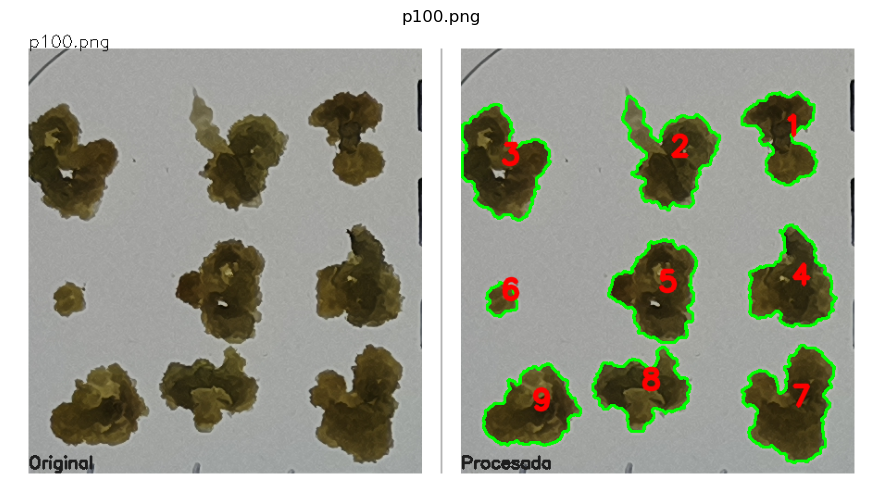

In [5]:
# ------------------ Comparativa ------------------
import os
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Funciones para que no pete con rutas que tengan tildes o eñes
def imread_unicode(path):
    try:
        # Uso numpy para leer el archivo porque cv2.imread da problemas con caracteres raros
        data = np.fromfile(path, dtype=np.uint8)
        img  = cv2.imdecode(data, cv2.IMREAD_COLOR)
        return img
    except Exception:
        return None

def imwrite_unicode(path, img_bgr):
    try:
        ext = os.path.splitext(path)[1].lower()
        if ext in ('.jpg', '.jpeg'):
            ok, enc = cv2.imencode('.jpg', img_bgr, [cv2.IMWRITE_JPEG_QUALITY, 95])
        else:
            ok, enc = cv2.imencode('.png', img_bgr, [cv2.IMWRITE_PNG_COMPRESSION, 3])
        if not ok: 
            return False
        enc.tofile(path) # Guardar usando tofile para evitar problemas de ruta
        return True
    except Exception:
        return False

# Para montar la imagen del "antes y después"
def generar_comparativa(img_original, img_procesada, nombre_img, out_dir="./comparativas_unicas/"):
    os.makedirs(out_dir, exist_ok=True)
    h, w = img_original.shape[:2]
    
    # Si los tamaños no cuadran, reescalamos la procesada para que encaje
    if img_procesada.shape[:2] != (h, w):
        img_procesada = cv2.resize(img_procesada, (w, h), interpolation=cv2.INTER_LINEAR)

    # Configuración del canvas (márgenes y separación)
    MARGIN, GAP, SEP_W = 20, 20, 2
    BG, SEP = (255, 255, 255), (180, 180, 180)
    total_w = MARGIN + w + GAP + SEP_W + GAP + w + MARGIN
    total_h = MARGIN + h + MARGIN
    canvas = np.full((total_h, total_w, 3), BG, dtype=np.uint8)

    # Colocamos las imágenes en su sitio dentro del canvas
    y0, xL = MARGIN, MARGIN
    xSep, xR = xL + w + GAP, xL + w + GAP + SEP_W + GAP
    canvas[y0:y0+h, xL:xL+w] = img_original
    canvas[y0:y0+h, xSep:xSep+SEP_W] = SEP
    canvas[y0:y0+h, xR:xR+w] = img_procesada

    # Ponemos los textos de "Original" y "Procesada"
    titulo = f"{nombre_img}"
    cv2.putText(canvas, titulo, (MARGIN, 18), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 1)
    cv2.putText(canvas, "Original",  (MARGIN, y0 + h - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (30,30,30), 2)
    cv2.putText(canvas, "Procesada", (xR,     y0 + h - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (30,30,30), 2)

    # Guardamos el resultado y lo mostramos por pantalla
    out_path = os.path.join(out_dir, f"comparativa_{os.path.splitext(nombre_img)[0]}.png")
    ok = imwrite_unicode(out_path, canvas)
    print(f"✅ Guardada: {out_path}" if ok else f"⚠️ No se pudo guardar: {out_path}")

    plt.figure(figsize=(12, 6))
    plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(titulo)
    plt.show()

# ------------------ Ejecución ------------------
# Intento usar la ruta que ya tengo, si no, uso la de por defecto
try:
    base = Path(folder_path)
except NameError:
    base = Path('./labelme_annotation/')

nombre_img = 'p100.png'
exts_validas = {'.png', '.jpg', '.jpeg', '.tif', '.tiff', '.PNG', '.JPG', '.JPEG'}

# 1) Primero miro si la imagen está en la carpeta raíz
ruta = base / nombre_img

# 2) Si no está ahí, la busco en todas las subcarpetas
if not ruta.is_file():
    stem = Path(nombre_img).stem.lower()
    ruta_encontrada = None
    for p in base.rglob('*'):
        if p.is_file():
            # Comparo nombres pasando todo a minúsculas para no liarme
            if p.name.lower() == nombre_img.lower() or (p.stem.lower() == stem and p.suffix in exts_validas):
                ruta_encontrada = p
                break
    if ruta_encontrada:
        ruta = ruta_encontrada
    else:
        raise FileNotFoundError(f"No hay manera de encontrar '{nombre_img}' en: {base.resolve()}")

# 3) Cargo la imagen original
img_bgr = imread_unicode(str(ruta))
if img_bgr is None:
    raise RuntimeError(f"Error al leer: {ruta}")

# 4) Aquí llamo a mi función de procesar
validos, img_proc_bgr = procesar_imagen(img_bgr)

# 5) Saco la comparativa final
generar_comparativa(img_bgr, img_proc_bgr, ruta.name, out_dir="./comparativas_unicas/")

RGB + HSV COMPLETO

Código (HSV/RGB) de segmentación con cálculo de área del callo (mm2)

Para elegir el espacio de color (RGB o HSV) en esta parte del código, solo hay que cambiar la variable: USE_RGB = True. Si la pones en True usas RGB y si la pones en False activas el filtro por HSV.

Este código es el específico para este experimento. Aquí incluyo la conversión a mm² ajustada al tamaño real de la placa Petri. Es el que uso para el fenotipado porque transforma los datos digitales en medidas reales de superficie.

In [6]:
# -*- coding: utf-8 -*-
"""
Análisis de callos vegetales - Tarea de Bioimágenes
Antonio Enrique Coll Meseguer — Belén Salar

Aquí hacemos todo el lío: 
- Usamos RGB o HSV según convenga.
- Metemos filtros para que el verde resalte (G > R y G > B).
- Si la máscara falla, el código intenta arreglarse solo bajando el listón.
- Al final tiramos de Watershed para separar lo que esté pegado y sacamos un reporte.
"""

import os
import csv
import time
import datetime
from pathlib import Path
import statistics as stats

import numpy as np
import cv2

# ===========================
# PARÁMETROS GLOBALES
# ===========================
# OJO: Cambiar esta ruta si movéis las fotos de sitio
folder_path   = r'C:\Users\anton\OneDrive\Escritorio\ABioimágenes\labelme_annotation\labelme_annotation'

# --- Configuración de escala para Temática C ---
# Factor de conversión: mm2 por cada píxel (basado en placa de 90mm)
FACTOR_MM2 = 0.0025 

# Ajustes de color
USE_RGB              = True     # Si lo ponemos en False, tira por HSV
NORMALIZE_LAB_CLAHE  = True     # Para que la luz no nos fastidie (ecualiza el canal L)

# Rangos para el modo HSV (por si el RGB no va bien)
HSV_BAJO         = np.array([10, 30, 30], dtype=np.uint8)
HSV_ALTO         = np.array([100, 255, 255], dtype=np.uint8)

# --- Configuración de la máscara RGB (buscando el verde) ---
R_MIN, R_MAX = 20, 210
G_MIN, G_MAX = 80, 255
B_MIN, B_MAX = 10, 150

# Queremos que el verde sea el que mande
DELTA_GR = 10    # El verde tiene que ganar al rojo por esto
DELTA_GB = 10    # Y al azul por esto

# ¿Qué porcentaje de verde hay sobre el total?
G_PROP_MIN = 0.36   # Al menos un 36% tiene que ser componente G
EPS_PROP   = 1e-3   # Para no dividir entre cero y que pete

# En el espacio LAB, el canal 'a' nos dice si es verde (valores bajos)
A_MAX = 128         
# -----------------------------------------------------------

# Configuración del procesado
AREA_MINIMA      = 300        # Menos de esto es ruido
DISK_ERODE       = 7          # Tamaño de la erosión para separar callos
PEAK_FRAC        = 0.65       
BG_DIL_ITERS     = 2          # Cuánto estiramos el fondo
MERGE_DIST       = 25         # Si dos trozos están pegados, los unimos
CIRC_MIN         = 0.12       # Para quitar cosas que no tengan forma de callo

# Mejoras para las semillas del Watershed
USE_SEEDS_PER_COMPONENT = True
PEAK_FRAC_COMP   = 0.55
MIN_PEAK_DIST    = 9

# Config de guardado
output_txt    = 'resultado_analisisplaca.txt'
output_csv    = 'resultado_analisisplaca.csv'
guardar_annot = True
carpeta_annot = './salidas_annot/'
RENAME_ANNOT_WITH_COUNT = True  # Para ver el número de callos en el nombre del archivo

METODO_WS_TAG = 'watershed + seeds (DT picos + erosión)'
EXTS_VALIDAS = {'.png', '.jpg', '.jpeg', '.tif', '.tiff'}

# ===========================
# LECTURA Y ESCRITURA (Rutas con tildes)
# ===========================
def imread_unicode(path: str):
    # Truco para que Windows no de error si la ruta tiene tildes o eñes
    try:
        data = np.fromfile(path, dtype=np.uint8)
        img  = cv2.imdecode(data, cv2.IMREAD_COLOR)
        return img
    except Exception:
        return None

def imwrite_unicode(path: str, img_bgr: np.ndarray) -> bool:
    # Lo mismo pero para guardar
    try:
        ext = os.path.splitext(path)[1].lower()
        if ext in ('.jpg', '.jpeg'):
            ok, enc = cv2.imencode('.jpg', img_bgr, [cv2.IMWRITE_JPEG_QUALITY, 95])
        else:
            ok, enc = cv2.imencode('.png', img_bgr, [cv2.IMWRITE_PNG_COMPRESSION, 3])
        if not ok:
            return False
        enc.tofile(path)
        return True
    except Exception:
        return False

# ===========================
# UTILIDADES
# ===========================
def centroid_from_mask(mask_uint8: np.ndarray):
    # Saca el centro (x,y) de una mancha
    M = cv2.moments(mask_uint8, binaryImage=True)
    if M["m00"] == 0:
        return None
    return (int(M["m10"]/M["m00"]), int(M["m01"]/M["m00"]))

def circularidad(contorno) -> float:
    # Mira cómo de "redondo" es el objeto
    area = cv2.contourArea(contorno)
    per  = cv2.arcLength(contorno, True)
    if area <= 0 or per <= 0:
        return 0.0
    return float(4.0 * np.pi * area / (per * per))

def local_maxima_nms(dist_img: np.ndarray, thr: float, min_dist: int) -> np.ndarray:
    # Encuentra los puntos más altos de la distancia transformada para poner semillas
    m = (dist_img >= thr).astype(np.uint8) * 255
    k = 2 * min_dist + 1
    max_filt = cv2.dilate(dist_img, cv2.getStructuringElement(cv2.MORPH_RECT, (k, k)))
    peaks = np.logical_and(dist_img >= max_filt - 1e-6, m > 0).astype(np.uint8) * 255
    num, lab = cv2.connectedComponents(peaks)
    out = np.zeros_like(peaks)
    for lbl in range(1, num):
        ys, xs = np.where(lab == lbl)
        if ys.size == 0:
            continue
        vals = dist_img[ys, xs]
        idx = np.argmax(vals)
        out[ys[idx], xs[idx]] = 255
    return out

def seeds_por_componente(mask_bin: np.ndarray, dist_blur: np.ndarray,
                         frac: float, min_dist: int) -> np.uint8:
    # Pone semillas individuales en cada mancha verde detectada
    seeds = np.zeros_like(mask_bin, dtype=np.uint8)
    n, lab = cv2.connectedComponents(mask_bin)
    for lbl in range(1, n):
        comp = (lab == lbl).astype(np.uint8) * 255
        if np.count_nonzero(comp) == 0:
            continue
        max_local = float(dist_blur[comp > 0].max())
        if max_local <= 0:
            continue
        thr = frac * max_local
        dist_local = dist_blur.copy()
        dist_local[comp == 0] = 0.0
        peaks = local_maxima_nms(dist_local, thr, min_dist)
        seeds = cv2.bitwise_or(seeds, peaks)
    return seeds

# ===========================
# FUNCIÓN PARA UNIR TROZOS PEQUEÑOS
# ===========================
def merge_small_regions(label_img: np.ndarray, min_area=AREA_MINIMA, merge_dist=MERGE_DIST):
    # Si un callo se ha partido en dos, esta función intenta pegarlo basándose en la distancia
    labels = np.unique(label_img)
    labels = labels[labels > 1] 

    areas = {}
    centroids = {}
    for lbl in labels:
        mask = (label_img == lbl).astype(np.uint8) * 255
        a = cv2.countNonZero(mask)
        areas[lbl] = a
        centroids[lbl] = centroid_from_mask(mask)

    merged_to = {}
    for lbl in labels:
        if areas[lbl] >= min_area:
            continue
        c_small = centroids[lbl]
        if c_small is None:
            continue
        best_lbl, best_d = None, 1e9
        for other in labels:
            if other == lbl or areas[other] < min_area:
                continue
            c_other = centroids[other]
            if c_other is None:
                continue
            d = np.hypot(c_small[0]-c_other[0], c_small[1]-c_other[1])
            if d < best_d:
                best_d, best_lbl = d, other
        if best_lbl is not None and best_d <= merge_dist:
            merged_to[lbl] = best_lbl

    new_labels = label_img.copy()
    for lbl_small, lbl_target in merged_to.items():
        new_labels[new_labels == lbl_small] = lbl_target

    areas_final = {}
    for lbl in np.unique(new_labels):
        if lbl <= 1:
            continue
        areas_final[lbl] = int(cv2.countNonZero((new_labels == lbl).astype(np.uint8)))

    return new_labels, areas_final

# ===========================
# SEGMENTACIÓN RGB (CON AUTO-ARREGLO)
# ===========================
def segmentacion_rgb_adaptativa(img_bgr: np.ndarray):
    # Aquí es donde buscamos los callos por color
    src_bgr = img_bgr
    if NORMALIZE_LAB_CLAHE:
        # Arreglamos la luz primero
        lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
        L, A, Bb = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        L_eq = clahe.apply(L)
        lab_eq = cv2.merge([L_eq, A, Bb])
        src_bgr = cv2.cvtColor(lab_eq, cv2.COLOR_LAB2BGR)

    rgb = cv2.cvtColor(src_bgr, cv2.COLOR_BGR2RGB)
    R = rgb[:,:,0].astype(np.int16)
    G = rgb[:,:,1].astype(np.int16)
    B = rgb[:,:,2].astype(np.int16)

    # Máscaras por canales individuales
    mG = ((G >= G_MIN) & (G <= G_MAX)).astype(np.uint8) * 255
    mR = ((R >= R_MIN) & (R <= R_MAX)).astype(np.uint8) * 255
    mB = ((B >= B_MIN) & (B <= B_MAX)).astype(np.uint8) * 255

    # Aplicamos las reglas de G > R y G > B
    rel1 = (G - R) > DELTA_GR
    rel2 = (G - B) > DELTA_GB
    mRel = np.logical_and(rel1, rel2).astype(np.uint8) * 255

    mask = cv2.bitwise_and(mG, cv2.bitwise_and(mR, mB))
    mask = cv2.bitwise_and(mask, mRel)

    # Calculamos la proporción de verde
    denom = (R + G + B).astype(np.float32) + EPS_PROP
    g_prop = (G.astype(np.float32) / denom)
    mProp = (g_prop >= G_PROP_MIN).astype(np.uint8) * 255
    mask = cv2.bitwise_and(mask, mProp)

    # Filtro extra con el canal 'a' de LAB
    lab2 = cv2.cvtColor(src_bgr, cv2.COLOR_BGR2LAB)
    a_chan = lab2[:,:,1] 
    mA = (a_chan <= A_MAX).astype(np.uint8) * 255
    mask = cv2.bitwise_and(mask, mA)

    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3,3), np.uint8), iterations=1)

    # AUTO-VERIFICACIÓN: Si no hay casi nada, abrimos la mano con los filtros
    h, w = mask.shape
    area_mask = int(cv2.countNonZero(mask))
    ratio = area_mask / float(h*w)

    if area_mask < 500:
        # Relajamos los parámetros un poco para pillar algo
        gp = max(0.30, G_PROP_MIN - 0.04)
        dgr = max(6, DELTA_GR - 4)
        dgb = max(6, DELTA_GB - 4)
        mG2 = ((G >= max(70, G_MIN - 10)) & (G <= G_MAX)).astype(np.uint8) * 255
        mR2 = ((R >= R_MIN) & (R <= min(220, R_MAX + 10))).astype(np.uint8) * 255
        mB2 = ((B >= B_MIN) & (B <= min(170, B_MAX + 10))).astype(np.uint8) * 255
        rel1b = (G - R) > dgr
        rel2b = (G - B) > dgb
        mRel2 = np.logical_and(rel1b, rel2b).astype(np.uint8) * 255
        denom2 = (R + G + B).astype(np.float32) + EPS_PROP
        g_prop2 = (G.astype(np.float32) / denom2)
        mProp2 = (g_prop2 >= gp).astype(np.uint8) * 255

        mask2 = cv2.bitwise_and(mG2, cv2.bitwise_and(mR2, mB2))
        mask2 = cv2.bitwise_and(mask2, mRel2)
        mask2 = cv2.bitwise_and(mask2, mProp2)
        mask2 = cv2.bitwise_and(mask2, mA)
        mask2 = cv2.morphologyEx(mask2, cv2.MORPH_OPEN, np.ones((3,3), np.uint8), iterations=1)

        if cv2.countNonZero(mask2) > area_mask:
            mask = mask2
            area_mask = int(cv2.countNonZero(mask))
            ratio = area_mask / float(h*w)

    # Si por el contrario hay demasiado, es que hemos pillado fondo, así que endurecemos
    if ratio > 0.30:
        gp = min(0.42, G_PROP_MIN + 0.04)
        dgr = DELTA_GR + 2
        dgb = DELTA_GB + 2
        mG3 = ((G >= G_MIN) & (G <= G_MAX)).astype(np.uint8) * 255
        mR3 = ((R >= R_MIN) & (R <= R_MAX)).astype(np.uint8) * 255
        mB3 = ((B >= B_MIN) & (B <= max(130, B_MAX - 20))).astype(np.uint8) * 255
        rel1c = (G - R) > dgr
        rel2c = (G - B) > dgb
        mRel3 = np.logical_and(rel1c, rel2c).astype(np.uint8) * 255
        denom3 = (R + G + B).astype(np.float32) + EPS_PROP
        mProp3 = ((G.astype(np.float32) / denom3) >= gp).astype(np.uint8) * 255

        mask3 = cv2.bitwise_and(mG3, cv2.bitwise_and(mR3, mB3))
        mask3 = cv2.bitwise_and(mask3, mRel3)
        mask3 = cv2.bitwise_and(mask3, mProp3)
        mask3 = cv2.bitwise_and(mask3, mA)
        mask3 = cv2.morphologyEx(mask3, cv2.MORPH_OPEN, np.ones((3,3), np.uint8), iterations=1)

        if cv2.countNonZero(mask3) < area_mask:
            mask = mask3
            area_mask = int(cv2.countNonZero(mask))
            ratio = area_mask / float(h*w)

    # Si después de todo sigue sin haber nada, tiramos de HSV como plan B
    if area_mask < 500:
        hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
        mask = cv2.inRange(hsv, HSV_BAJO, HSV_ALTO)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3,3), np.uint8), iterations=1)

    return mask

# ===========================
# EL MOTOR DEL PROCESADO
# ===========================
def procesar_imagen(img_bgr: np.ndarray, nombre_archivo: str = None):
    # Quitamos ruido primero
    img_suave = cv2.medianBlur(img_bgr, 5)

    # Elegimos espacio de color
    if USE_RGB:
        mask = segmentacion_rgb_adaptativa(img_suave)
        modo_color = "RGB(adapt)"
    else:
        hsv = cv2.cvtColor(img_suave, cv2.COLOR_BGR2HSV)
        mask = cv2.inRange(hsv, HSV_BAJO, HSV_ALTO)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=1)
        modo_color = "HSV"

    # Preparación para el Watershed (erosión y semillas)
    se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (DISK_ERODE, DISK_ERODE))
    sure_fg_erode = cv2.erode(mask, se, iterations=1)

    dist = cv2.distanceTransform(mask, cv2.DIST_L2, 5).astype(np.float32)
    dist_blur = cv2.GaussianBlur(dist, (3, 3), 0)

    # Generamos los puntos centrales de los callos
    if USE_SEEDS_PER_COMPONENT:
        peaks_comp = seeds_por_componente(mask, dist_blur, frac=PEAK_FRAC_COMP, min_dist=MIN_PEAK_DIST)
        seeds = cv2.bitwise_or(sure_fg_erode, peaks_comp)
    else:
        kmax = cv2.getStructuringElement(cv2.MORPH_RECT, (DISK_ERODE + 2, DISK_ERODE + 2))
        dist_dil = cv2.dilate(dist_blur, kmax)
        peaks_eq = dist_blur >= (dist_dil - 1e-6)
        height_thr = PEAK_FRAC * (dist_blur.max() if dist_blur.max() > 0 else 1.0)
        peaks_h = dist_blur >= height_thr
        peaks = np.logical_and(peaks_eq, peaks_h).astype(np.uint8) * 255
        seeds = cv2.bitwise_or(sure_fg_erode, peaks)

    # Fondo y zona de conflicto
    sure_bg = cv2.dilate(mask, np.ones((3, 3), np.uint8), iterations=BG_DIL_ITERS)
    unknown = cv2.subtract(sure_bg, seeds)

    # Aplicamos Watershed para inundar y separar
    num_markers, markers = cv2.connectedComponents(seeds)
    markers = markers.astype(np.int32) + 1  
    markers[unknown == 255] = 0
    markers = cv2.watershed(img_bgr, markers)

    # Pegamos los fragmentos que se hayan quedado sueltos
    labels_merged, _ = merge_small_regions(markers, min_area=AREA_MINIMA, merge_dist=MERGE_DIST)

    # Filtramos por tamaño y si son muy alargados (circularidad)
    objetos_validos = []
    for lbl in np.unique(labels_merged):
        if lbl <= 1:
            continue
        mask_lbl = (labels_merged == lbl).astype(np.uint8) * 255
        a = cv2.countNonZero(mask_lbl)
        if a >= AREA_MINIMA:
            cnts, _ = cv2.findContours(mask_lbl, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if cnts:
                c = max(cnts, key=cv2.contourArea)
                circ = circularidad(c)
                if circ < CIRC_MIN:
                    continue
                objetos_validos.append((c, a))

    # Dibujamos los contornos y el número de callo
    img_draw = img_bgr.copy()
    for i, (c, a) in enumerate(objetos_validos, start=1):
        cv2.drawContours(img_draw, [c], -1, (0, 255, 0), 2)
        M = cv2.moments(c)
        if M["m00"] != 0:
            cx, cy = int(M["m10"]/M["m00"]), int(M["m01"]/M["m00"])
            etiqueta = str(i)
            # Dibujo la letra con borde negro para que se vea bien
            cv2.putText(img_draw, etiqueta, (cx, cy),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 3, cv2.LINE_AA)
            cv2.putText(img_draw, etiqueta, (cx, cy),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,   0,   0), 1, cv2.LINE_AA)

    # Ponemos la barra negra arriba con el resumen
    num_callos = len(objetos_validos)
    alto_cartela = 36
    overlay = img_draw.copy()
    h, w = img_draw.shape[:2]
    cv2.rectangle(overlay, (0, 0), (w, alto_cartela), (0, 0, 0), -1)
    alpha = 0.35
    img_draw = cv2.addWeighted(overlay, alpha, img_draw, 1 - alpha, 0)
    texto_izq = f"{nombre_archivo if nombre_archivo else 'Segmentación'} — {modo_color}"
    texto_der = f"Callos: {num_callos}"
    cv2.putText(img_draw, texto_izq, (12, 25),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2, cv2.LINE_AA)
    (tw, th), _ = cv2.getTextSize(texto_der, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
    cv2.putText(img_draw, texto_der, (w - tw - 12, 25),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2, cv2.LINE_AA)

    return objetos_validos, img_draw, METODO_WS_TAG

# ===========================
# GENERACIÓN DE INFORMES
# ===========================
def fmt_np_uint8_array(arr):
    # Para escribir los arrays de numpy de forma bonita en el txt
    vals = [f"np.uint8({int(x)})" for x in np.array(arr, dtype=np.uint8)]
    return "[" + ", ".join(vals) + "]"

def generar_reporte():
    base = Path(folder_path)
    if not base.is_dir():
        raise FileNotFoundError(f"No existe la carpeta: {folder_path}")

    fotos_paths = sorted([p for p in base.glob('*') if p.is_file() and p.suffix.lower() in EXTS_VALIDAS])
    print(f"Procesando {len(fotos_paths)} imágenes desde: {base.resolve()}")

    now   = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    linea = "-"*64
    t0_total = time.time()

    resumen_por_imagen = [] 
    tiempos_por_imagen = [] 
    errores_lectura    = []
    registros_csv      = [] 

    with open(output_txt, 'w', encoding='utf-8') as fw:
        fw.write("REPORTE DE CONTAJE AUTOMÁTICO - TEMÁTICA C\n")
        fw.write(f"Fecha/Hora: {now}\n")
        fw.write(f"Factor de escala: 1 px = {FACTOR_MM2} mm2\n\n")
        fw.write("Parámetros utilizados:\n")
        fw.write(f"  AREA_MINIMA   = {AREA_MINIMA} px\n")
        fw.write(f"  DISK_ERODE    = {DISK_ERODE}\n")
        fw.write(f"  PEAK_FRAC     = {PEAK_FRAC}\n")
        fw.write(f"  BG_DIL_ITERS  = {BG_DIL_ITERS}\n")
        fw.write(f"  MERGE_DIST    = {MERGE_DIST} px\n")
        fw.write(f"  CIRC_MIN      = {CIRC_MIN}\n")
        fw.write(f"  Modo WS       = {METODO_WS_TAG}\n")
        if USE_RGB:
            fw.write(f"  Rango RGB (adapt): R[{R_MIN}–{R_MAX}], G[{G_MIN}–{G_MAX}], B[{B_MIN}–{B_MAX}]\n")
        else:
            fw.write(f"  Rango HSV      = bajo{fmt_np_uint8_array(HSV_BAJO)} / alto{fmt_np_uint8_array(HSV_ALTO)}\n")
        
        fw.write("\nRESULTADOS POR IMAGEN:\n")

        with open(output_csv, 'w', newline='', encoding='utf-8') as fcsv:
            writer = csv.writer(fcsv)
            # Añadido area_mm2 a la cabecera del CSV
            writer.writerow(["imagen", "id_callo", "area_px", "area_mm2", "centroide_x", "centroide_y", "circularidad"])

            for p in fotos_paths:
                archivo = p.name
                ruta    = str(p)
                t_ini   = time.time()

                img     = imread_unicode(ruta)
                if img is None:
                    print(f"⚠️ No se pudo leer {archivo}.")
                    errores_lectura.append(archivo)
                    fw.write(f"  Foto: {archivo} | ERROR de lectura\n{linea}\n")
                    continue

                validos, img_dibujo, metodo_ws = procesar_imagen(img, nombre_archivo=archivo)
                n_callos = len(validos)
                resumen_por_imagen.append((archivo, n_callos))

                t_img = time.time() - t_ini
                tiempos_por_imagen.append((archivo, t_img))

                fw.write(f"  Foto: {archivo} | Detectados: {n_callos} | Tiempo: {t_img:.2f}s\n")

                for i, (c, area_px) in enumerate(validos, start=1):
                    # --- CÁLCULO DE MM2 ---
                    area_mm2 = float(area_px) * FACTOR_MM2

                    M = cv2.moments(c)
                    cx, cy = (int(M["m10"]/M["m00"]), int(M["m01"]/M["m00"])) if M["m00"] != 0 else (-1, -1)
                    
                    area_c = cv2.contourArea(c)
                    per_c  = cv2.arcLength(c, True)
                    circ_val = float(4.0 * np.pi * area_c / (per_c * per_c)) if (area_c > 0 and per_c > 0) else 0.0

                    # Añadido mm2 al reporte de texto
                    fw.write(f"     Callo {i}: {float(area_px):.1f} px ({area_mm2:.3f} mm2) | centroide=({cx},{cy}) | circ={circ_val:.3f}\n")
                    # Añadido mm2 al CSV
                    writer.writerow([archivo, i, f"{area_px:.1f}", f"{area_mm2:.3f}", cx, cy, f"{circ_val:.3f}"])

                fw.write("\n")

                if guardar_annot:
                    os.makedirs(carpeta_annot, exist_ok=True)
                    sufijo = f"_callos{n_callos}" if RENAME_ANNOT_WITH_COUNT else ""
                    out_name = os.path.join(carpeta_annot, f"annot_{os.path.splitext(archivo)[0]}{sufijo}.png")
                    imwrite_unicode(out_name, img_dibujo)

        # Estadísticas finales para el reporte
        counts = [n for _, n in resumen_por_imagen]
        total_callos   = sum(counts) if counts else 0
        media_callos   = (total_callos / len(counts)) if counts else 0.0
        mediana_callos = stats.median(counts) if counts else 0.0
        min_callos     = min(counts) if counts else 0
        max_callos     = max(counts) if counts else 0
        sd_callos      = stats.pstdev(counts) if counts else 0.0
        cero_callos    = sum(1 for n in counts if n == 0)

        t_total = time.time() - t0_total
        t_med   = (sum(t for _, t in tiempos_por_imagen) / len(tiempos_por_imagen)) if tiempos_por_imagen else 0.0

        fw.write("RESUMEN GLOBAL:\n")
        fw.write(f"  Imágenes analizadas   : {len(counts)}\n")
        fw.write(f"  Total de callos       : {total_callos}\n")
        fw.write(f"  Media/Mediana         : {media_callos:.2f} / {mediana_callos:.2f}\n")
        fw.write(f"  Desviación típica     : {sd_callos:.2f}\n")
        fw.write(f"  Mín/Máx detectados     : {min_callos} / {max_callos}\n")
        fw.write(f"  Imágenes vacías       : {cero_callos}\n")
        fw.write(f"  Tiempo total           : {t_total:.1f}s\n")

        top3   = sorted(resumen_por_imagen, key=lambda x: x[1], reverse=True)[:3]
        fw.write("  Top 3 con más callos:\n")
        for (img_name, n) in top3:
            fw.write(f"    - {img_name}: {n}\n")
        fw.write(("-"*64) + "\n")

    print(f"✅ Todo listo. TXT: {output_txt} | CSV: {output_csv}")

# ===========================
# INICIO DEL SCRIPT
# ===========================
def main():
    generar_reporte()

if __name__ == '__main__':
    main()

Procesando 16 imágenes desde: C:\Users\anton\OneDrive\Escritorio\ABioimágenes\labelme_annotation\labelme_annotation
✅ Todo listo. TXT: resultado_analisisplaca.txt | CSV: resultado_analisisplaca.csv


Gráfica: Distribución de Callos

Aquí represento los resultados finales en una gráfica de barras.

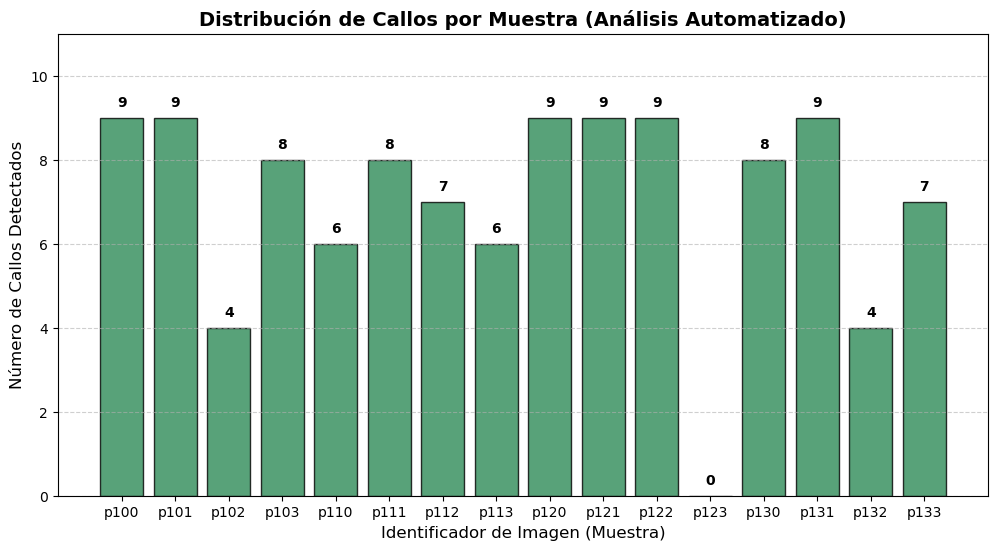

In [8]:
import matplotlib.pyplot as plt

# Meto aquí los datos que han salido en el reporte para hacer la gráfica
imagenes = ['p100', 'p101', 'p102', 'p103', 'p110', 'p111', 'p112', 'p113', 
            'p120', 'p121', 'p122', 'p123', 'p130', 'p131', 'p132', 'p133']

callos = [9, 9, 4, 8, 6, 8, 7, 6, 9, 9, 9, 0, 8, 9, 4, 7]

# Configuro el tamaño de la gráfica para que no se vea todo amontonado
plt.figure(figsize=(12, 6))
bars = plt.bar(imagenes, callos, color='seagreen', edgecolor='black', alpha=0.8)

# Pongo los títulos y nombres de los ejes
plt.title('Distribución de Callos por Muestra (Análisis Automatizado)', fontsize=14, fontweight='bold')
plt.xlabel('Identificador de Imagen (Muestra)', fontsize=12)
plt.ylabel('Número de Callos Detectados', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.ylim(0, 11) # Dejo hueco arriba para que no choquen los números con el borde

# Este bucle es para poner el número exacto encima de cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.2, yval, ha='center', va='bottom', fontweight='bold')

# Guardo el gráfico en un archivo para pegarlo luego en el documento de la memoria
plt.savefig('grafica_resultados.png', dpi=300)
plt.show()

Comparativa Automático vs Manual (Ground Truth)

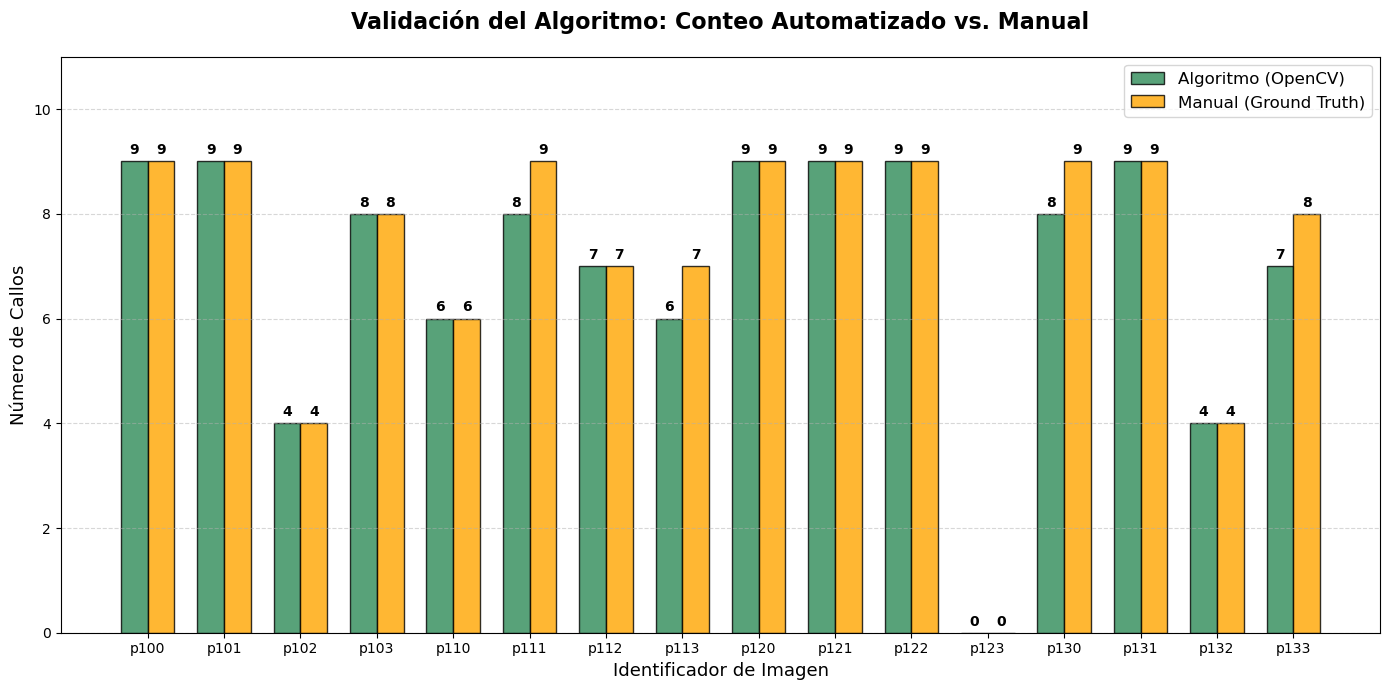

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Datos del análisis
imagenes = ['p100', 'p101', 'p102', 'p103', 'p110', 'p111', 'p112', 'p113', 
            'p120', 'p121', 'p122', 'p123', 'p130', 'p131', 'p132', 'p133']

# Datos del Algoritmo (112 en total)
conteo_algo = [9, 9, 4, 8, 6, 8, 7, 6, 9, 9, 9, 0, 8, 9, 4, 7]

# Datos Manuales / Ground Truth (115 en total)
# He sumado +1 en las muestras donde indicaste discrepancia
conteo_manual = [9, 9, 4, 8, 6, 9, 7, 7, 9, 9, 9, 0, 9, 9, 4, 8]

x = np.arange(len(imagenes))  # Localización de las etiquetas
width = 0.35  # Ancho de las barras

fig, ax = plt.subplots(figsize=(14, 7))

# Creamos las dos barras (Algoritmo vs Manual)
rects1 = ax.bar(x - width/2, conteo_algo, width, label='Algoritmo (OpenCV)', color='seagreen', edgecolor='black', alpha=0.8)
rects2 = ax.bar(x + width/2, conteo_manual, width, label='Manual (Ground Truth)', color='orange', edgecolor='black', alpha=0.8)

# Añadimos textos y etiquetas
ax.set_title('Validación del Algoritmo: Conteo Automatizado vs. Manual', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Identificador de Imagen', fontsize=13)
ax.set_ylabel('Número de Callos', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(imagenes)
ax.legend(fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_ylim(0, 11)

# Función para poner etiquetas sobre las barras
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 puntos de offset vertical
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.savefig('validacion_conteo.png', dpi=300)
plt.show()